In [126]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from IPython.display import display
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [127]:
file_path = '/content/drive/My Drive/ECGR 4105/Datasets/D3.csv'
df = pd.read_csv(file_path)
display(df)

,X1,X2,X3,Y
0,0.000000,3.440000,0.440000,4.387545
1,0.040404,0.134949,0.888485,2.679650
2,0.080808,0.829899,1.336970,2.968490
3,0.121212,1.524848,1.785455,3.254065
4,0.161616,2.219798,2.233939,3.536375
...,...,...,...,...
95,3.838384,1.460202,3.046061,-4.440595
96,3.878788,2.155152,3.494545,-4.458663
97,3.919192,2.850101,3.943030,-4.479995
98,3.959596,3.545051,0.391515,-3.304593


In [128]:
X1 = df.values[:, 0]
X2 = df.values[:, 1]
X3 = df.values[:, 2]
y  = df.values[:, 3]

m = len(y)

In [129]:
X_0 = np.ones((m,1))

X_1 = X1.reshape(m,1)
X_2 = X2.reshape(m,1)
X_3 = X3.reshape(m,1)

In [130]:
def compute_cost(X, y, theta):

  predictions = X.dot(theta)
  errors = np.subtract(predictions, y)
  sqrErrors = np.square(errors)
  J = 1 / (2 * m) * np.sum(sqrErrors)
  return J

In [131]:
def gradient_descent(X, y, theta, alpha, iterations):

  m = len(y)
  cost_history = np.zeros(iterations)

  for i in range(iterations):
    predictions = X.dot(theta)
    errors = np.subtract(predictions, y)
    sum_delta = (alpha / m) * X.transpose().dot(errors)
    theta -= sum_delta
    cost_history[i] = compute_cost(X, y, theta)

  return theta, cost_history

In [132]:
iterations = 1500
alpha = 0.05

In [133]:
def regression_plot(X, y, theta):

  plt.scatter(X[:, 1], y, color='red', marker='+', label='Training Data')

  plt.plot(X[:, 1], X.dot(theta), color='green', label='Linear Regression')

  plt.rcParams["figure.figsize"] = (10, 6)
  plt.grid(True)
  plt.title('Linear Regression Fit')
  plt.legend()

  plt.show()

In [134]:
def convergence_plot(cost_history):

  plt.plot(range(1, iterations + 1), cost_history, color='blue')
  plt.rcParams["figure.figsize"] = (10, 6)
  plt.grid(True)

  plt.xlabel('Number of iterations')
  plt.ylabel('Cost (J)')
  plt.title('Convergence of gradient descent')

  plt.show()

Final value of theta (X1 Explanatory) = [ 5.9279486  -2.03833651]
cost_history = [5.32852962 5.18676104 5.07204859 ... 0.98499308 0.98499308 0.98499308]


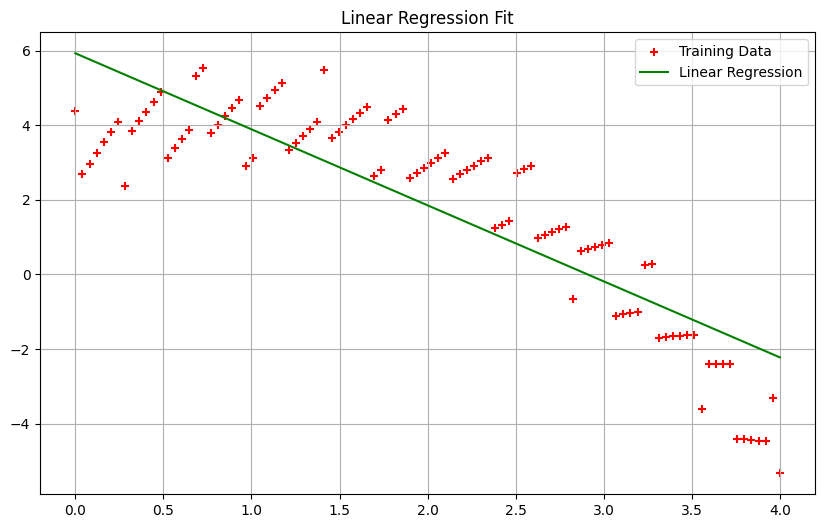

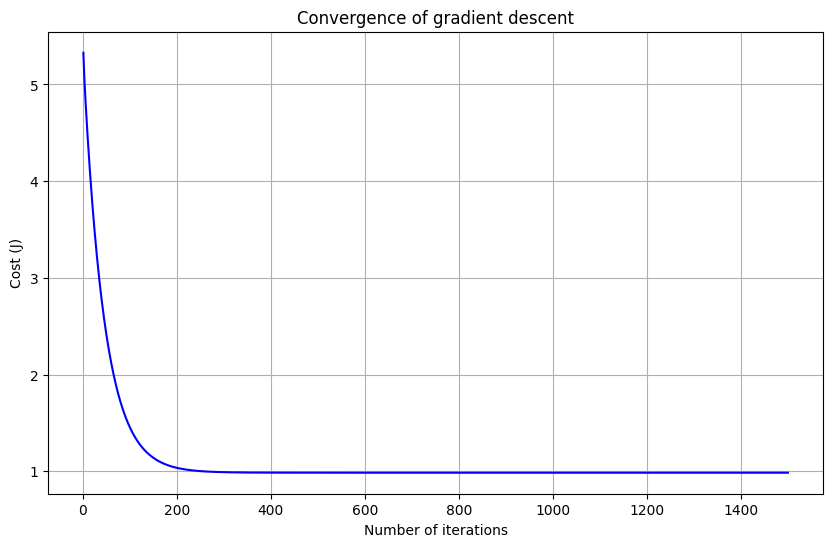

In [135]:
# Isolate X1 as the explanatory variable
theta = np.zeros(2)
X = np.hstack((X_0, X_1))

theta, cost_history = gradient_descent(X, y, theta, alpha, iterations)
print('Final value of theta (X1 Explanatory) =', theta)
print('cost_history =', cost_history)

regression_plot(X, y, theta)
convergence_plot(cost_history)

Final value of theta (X2 Explanatory) = [0.73606041 0.55760762]
cost_history = [4.5369622  4.06234927 3.83409365 ... 3.59936602 3.59936602 3.59936602]


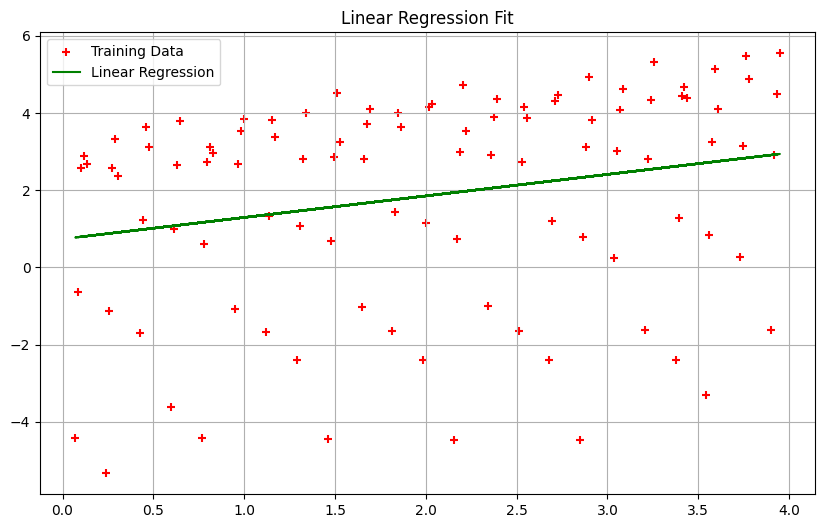

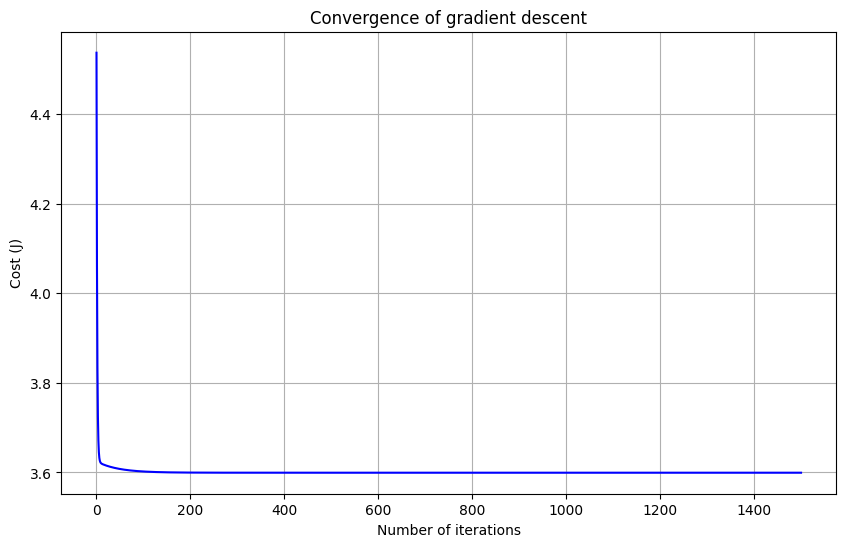

In [136]:
# Isolate X2 as the explanatory variable
theta = np.zeros(2)
X = np.hstack((X_0, X_2))

theta, cost_history = gradient_descent(X, y, theta, alpha, iterations)
print('Final value of theta (X2 Explanatory) =', theta)
print('cost_history =', cost_history)

regression_plot(X, y, theta)
convergence_plot(cost_history)

Final value of theta (X3 Explanatory) = [ 2.87142199 -0.52048284]
cost_history = [5.00990921 4.74622414 4.60645259 ... 3.62945112 3.62945112 3.62945112]


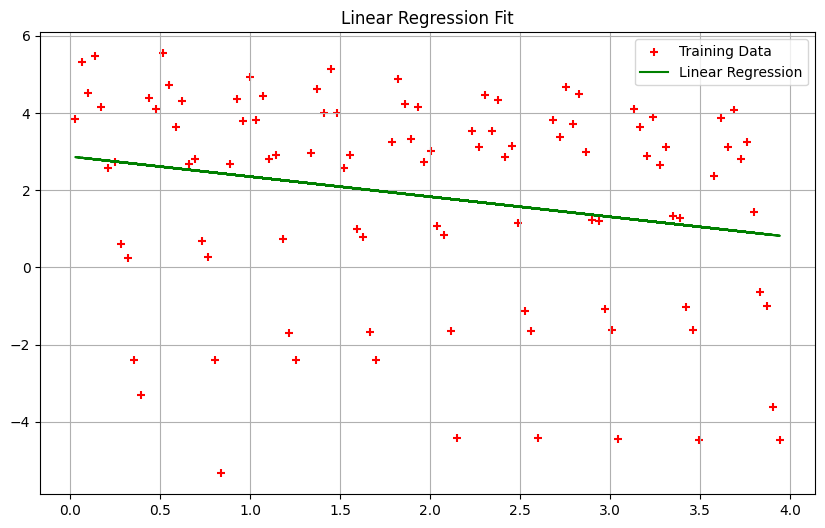

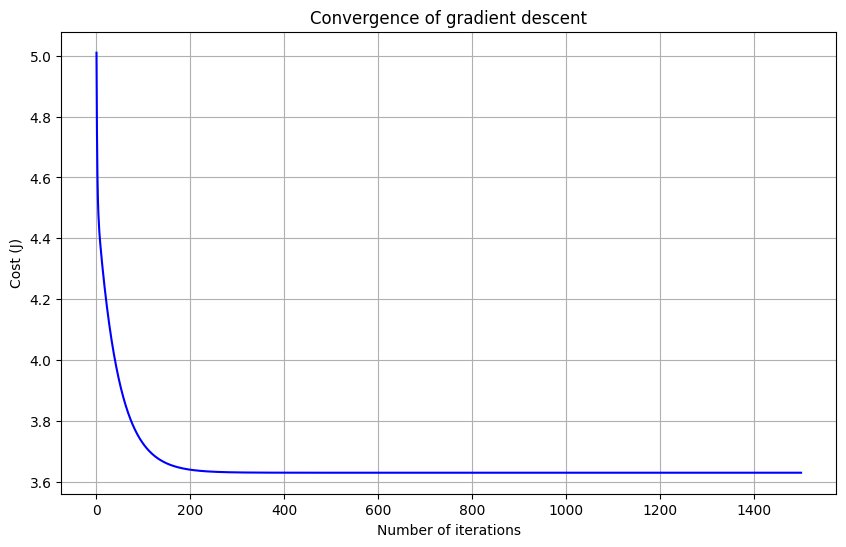

In [137]:
# Isolate X3 as the explanatory variable
theta = np.zeros(2)
X = np.hstack((X_0, X_3))

theta, cost_history = gradient_descent(X, y, theta, alpha, iterations)
print('Final value of theta (X3 Explanatory) =', theta)
print('cost_history =', cost_history)

regression_plot(X, y, theta)
convergence_plot(cost_history)

Final value of theta (All Explanatory) = [ 5.31128136 -2.0033116   0.5330402  -0.26517886]
cost_history = [4.35632837 3.99754934 3.73994659 ... 0.73846469 0.73846469 0.73846469]


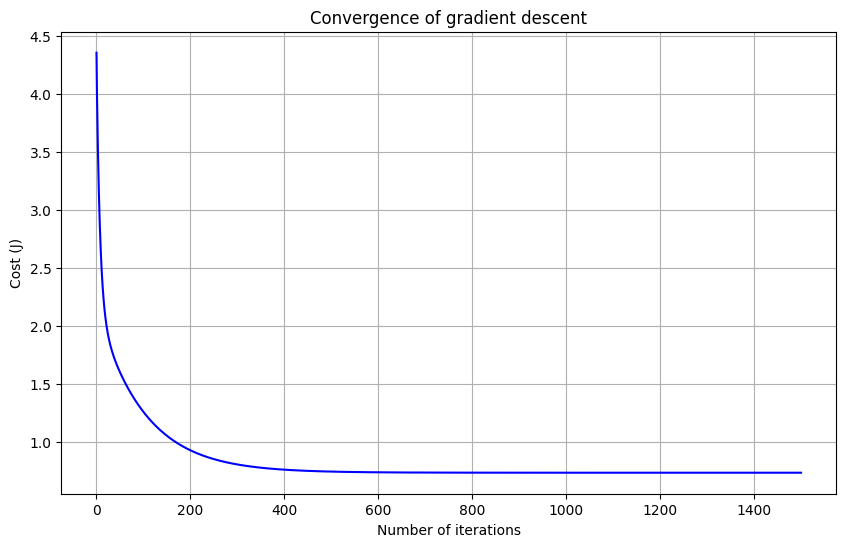

In [138]:
# Combine all three explanatory variables
theta = np.zeros(4)
X = np.hstack((X_0, X_1, X_2, X_3))

theta, cost_history = gradient_descent(X, y, theta, alpha, iterations)
print('Final value of theta (All Explanatory) =', theta)
print('cost_history =', cost_history)

convergence_plot(cost_history)

In [141]:
def predict_y(x1, x2, x3):
  return theta[0] + x1 * theta[1] + x2 * theta[2] + x3 * theta[3]

In [143]:
print(predict_y(1,1,1))
print(predict_y(2,0,4))
print(predict_y(3,2,1))

3.5758310955346353
0.24394270393310014
0.10224809362461512
